# Feature Extraction

## Purpose

This notebook extracts machine learning features from the UrbanSound8K dataset.

The extracted features will later be used to train classification models capable of identifying urban acoustic events relevant to noise governance.

The notebook performs:

1. Dataset loading and inspection
2. Class distribution analysis
3. Audio signal visualization
4. Spectrogram generation
5. MFCC feature extraction
6. Feature dataset creation

The output of this notebook will be a structured feature dataset stored in:

ml/data/features/

In [3]:
import os
import sys
from pathlib import Path

import librosa
import librosa.display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

print("Libraries loaded successfully")

Libraries loaded successfully


## Configure Dataset Paths

This section defines the location of the UrbanSound8K dataset and metadata file.

In [4]:
DATASET_PATH = Path("../data/raw/UrbanSound8K")
METADATA_PATH = DATASET_PATH / "UrbanSound8K.csv"

print("Dataset exists:", DATASET_PATH.exists())
print("Metadata exists:", METADATA_PATH.exists())

Dataset exists: True
Metadata exists: True


## Load Metadata

UrbanSound8K provides metadata describing each audio file and its associated sound category.

In [5]:
metadata = pd.read_csv(METADATA_PATH)

print("Shape:", metadata.shape)

metadata.head()

Shape: (8732, 8)


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [6]:
metadata["class"].value_counts()

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

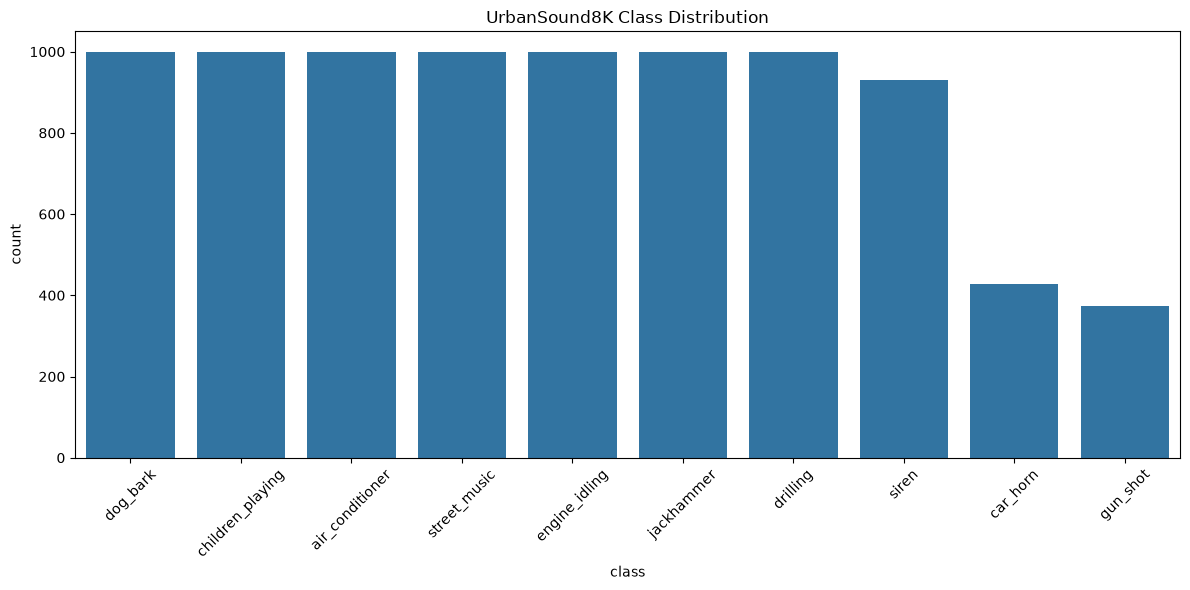

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=metadata,
    x="class",
    order=metadata["class"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("UrbanSound8K Class Distribution")

plt.tight_layout()
plt.show()

## Load Example Audio File

A sample audio recording is loaded for signal inspection.

In [8]:
sample_row = metadata.iloc[0]

fold = sample_row["fold"]
filename = sample_row["slice_file_name"]

audio_path = DATASET_PATH / f"fold{fold}" / filename

print(audio_path)

audio, sr = librosa.load(
    audio_path,
    sr=22050
)

print("Sample Rate:", sr)
print("Audio Length:", len(audio))

..\data\raw\UrbanSound8K\fold5\100032-3-0-0.wav


c:\Users\cyuba\Documents\LEARN\CAPSTONE\Noise\Urban-Noise-Governance-System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample Rate: 22050
Audio Length: 7002


## Waveform Visualization

Waveforms provide a time-domain representation of sound signals.

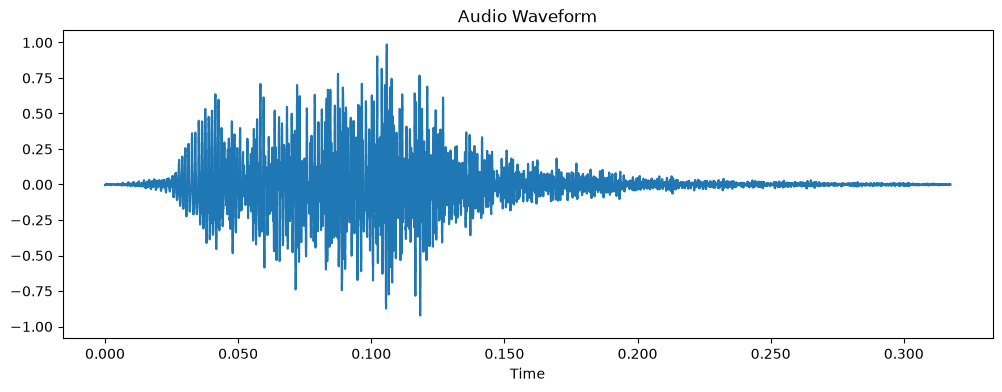

In [9]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Audio Waveform")

plt.show()

## Spectrogram Visualization

Spectrograms show how frequency content changes over time and are commonly used for acoustic event classification.

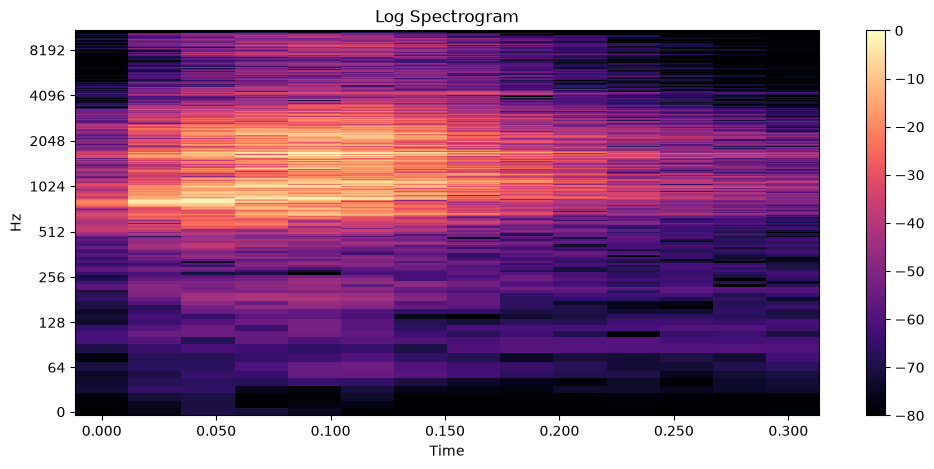

In [10]:
D = librosa.amplitude_to_db(
    np.abs(librosa.stft(audio)),
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    D,
    sr=sr,
    x_axis="time",
    y_axis="log"
)

plt.colorbar()

plt.title("Log Spectrogram")

plt.show()

## MFCC Feature Extraction

Mel Frequency Cepstral Coefficients (MFCCs) capture important spectral properties of audio signals and are widely used in sound classification.

In [11]:
mfccs = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

print("MFCC Shape:", mfccs.shape)

MFCC Shape: (40, 14)


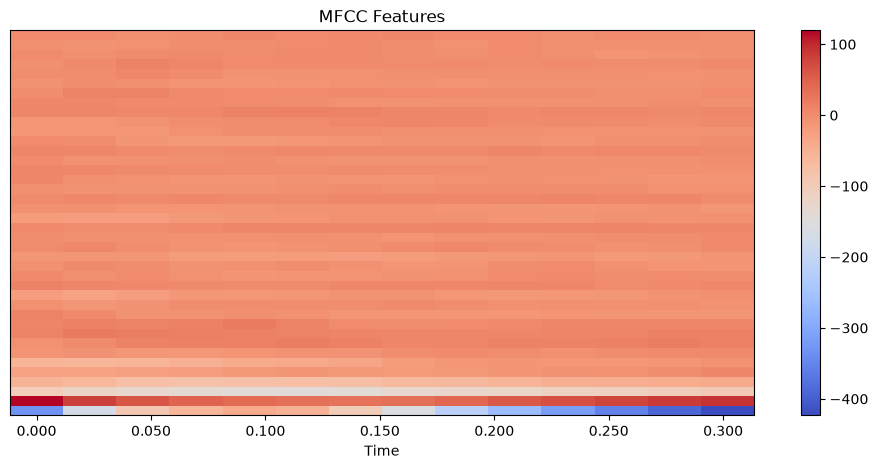

In [12]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfccs,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()

## Feature Extraction Function

This function extracts a fixed-length feature vector from an audio recording by averaging MFCC coefficients.

In [15]:
def extract_mfcc(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=22050
    )

    mfccs = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    mfccs_scaled = np.mean(
        mfccs.T,
        axis=0
    )

    return mfccs_scaled

## Test Feature Extraction

In [16]:
features = extract_mfcc(audio_path)

print(features.shape)

(40,)


## Save Sample Feature

This confirms that feature extraction is working correctly before processing the full dataset.

In [17]:
sample_df = pd.DataFrame([features])

FEATURE_DIR = Path("../data/features")

FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

sample_df.to_csv(
    FEATURE_DIR / "sample_features.csv",
    index=False
)

print("Feature file saved")

Feature file saved
